# Rossmann Store Sales — Red Neuronal con Entradas Heterogéneas
**Práctica B3-T5** · Predicción de series temporales de ventas

**Persona:** Dani &nbsp;|&nbsp; **Equipo:** Óscar · Dani · Fernando

---

### Enfoque
Modelo **many-to-one** con dos ramas heterogéneas:
- **Rama recurrente (LSTM):** historia temporal de cada tienda (ventas normalizadas, promo, features cíclicas de calendario, festivos, tendencia).
- **Rama densa (embeddings + numéricas):** atributos estáticos de la tienda (identidad, tipo, surtido, competencia).

La señal predictiva en Rossmann está dominada por: día de la semana, promociones, festivos y **la identidad de cada tienda**. Por eso son críticos el *embedding* de `Store` y la **normalización de ventas por tienda** (log1p + z-score), ambos ya implementados en `src/`.

El preprocesado, el modelo y la evaluación son compartidos por el equipo (`src/`), de modo que las métricas de los tres miembros sean directamente comparables. `src/evaluate.py` es el **contrato común** y no se modifica.

## 0 · Configuración del entorno

> **Importante (entorno local):** la GPU se desactiva *antes* de importar TensorFlow.
> En un equipo con GPU Blackwell (RTX 50xx) la build de TF-GPU puede colgarse indefinidamente,
> así que forzamos ejecución en CPU. Este dataset entrena bien en CPU.

In [1]:
import os

# --- Forzar CPU ANTES de cualquier import de TensorFlow ---
# (imprescindible en local con GPU Blackwell incompatible con TF-GPU)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # silencia logs de info de TF

import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

# --- Semilla global para reproducibilidad ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Confirmar que TF NO ve ninguna GPU (debe imprimir lista vacía)
print("TF version:", tf.__version__)
print("GPUs visibles:", tf.config.list_physical_devices("GPU"), "(debe estar vacío)")

TF version: 2.21.0
GPUs visibles: [] (debe estar vacío)


In [2]:
# --- Rutas y acceso al paquete src/ del equipo ---
# Este notebook vive en notebooks/, así que la raíz del proyecto es el directorio padre.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DATA_DIR    = os.path.join(PROJECT_ROOT, "data")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Módulos compartidos del equipo
import src.preprocessing as prep
import src.model         as mdl
import src.evaluate      as ev

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:    ", DATA_DIR)
print("Tiendas objetivo (evaluate.py):", ev.TARGET_STORES)

PROJECT_ROOT: c:\Users\danie\Desktop\MIAX - BME\Bloque 3 - Inteligencia Artificial Básica\TAREA_ENTRADAS_HETEROGENEAS
DATA_DIR:     c:\Users\danie\Desktop\MIAX - BME\Bloque 3 - Inteligencia Artificial Básica\TAREA_ENTRADAS_HETEROGENEAS\data
Tiendas objetivo (evaluate.py): [1, 2, 3, 4, 5, 562, 682, 733, 769]


## 1 · Carga de datos

Cargamos los datos crudos: `train.csv` (histórico de ventas diarias por tienda) y
`store.csv` (atributos estáticos de cada tienda: tipo, surtido, competencia, promociones).

In [3]:
train_raw, store_raw = prep.load_raw_data(DATA_DIR)

print(f"train: {train_raw.shape}  | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}  | {store_raw.Store.nunique()} tiendas")
print()
print("Columnas train:", list(train_raw.columns))
print("Columnas store:", list(store_raw.columns))
train_raw.head()

train: (1001599, 10)  | 2013-01-01 → 2015-07-17
store: (1115, 10)  | 1115 tiendas

Columnas train: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id']
Columnas store: ['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931


## 2 · Partición temporal

El split es **temporal** (no aleatorio): entrenamos con el pasado y validamos/testeamos
con el futuro, para no contaminar el modelo con información posterior (*leakage*).

Las fechas de corte están fijadas en `src/evaluate.py` como **contrato del equipo** —
no se redefinen aquí, se importan. Así los tres miembros evaluamos sobre exactamente
los mismos periodos.

| Split | Periodo |
|-------|---------|
| **Train** | hasta 2014-09-30 |
| **Val**   | 2014-10-01 → 2014-12-31 |
| **Test**  | desde 2015-01-01 |

El R² se mide sobre las **9 tiendas objetivo**, en escala de ventas original (euros),
solo en días abiertos. *(Nota: el enunciado menciona "10 tiendas" pero la lista del
contrato tiene 9; lo recogemos en la reflexión final.)*

In [4]:
print("Cortes temporales (contrato del equipo):")
print(f"  Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"  Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"  Test:   desde            {ev.SPLIT_TEST_START.date()}")
print(f"\nTiendas objetivo ({len(ev.TARGET_STORES)}): {ev.TARGET_STORES}")

Cortes temporales (contrato del equipo):
  Train:  hasta            2014-09-30
  Val:    2014-10-01 → 2014-12-31
  Test:   desde            2015-01-01

Tiendas objetivo (9): [1, 2, 3, 4, 5, 562, 682, 733, 769]


## 3 · Preprocesado

Pipeline implementado en `src/preprocessing.py`, ejecutado en el orden definido por el módulo.
Cada paso tiene una justificación:

1. **`clean_train`** — elimina días cerrados (`Open==0`, ventas=0 por definición) y anomalías
   (`Sales==0` con tienda abierta). Entrenar con ceros estructurales distorsionaría el modelo.
2. **`merge_store_features`** — une los atributos estáticos de `store.csv` e imputa nulos de competencia.
3. **`encode_categoricals`** — label-encoding de categóricas → índices enteros para los *embeddings*.
4. **`engineer_features`** — features cíclicas de calendario (sin/cos), edad de la competencia y
   tendencia lineal global.
5. **`temporal_split`** — separa en train/val/test por las fechas del contrato.
6. **`build_store_normalizer` + `normalize_sales`** — normaliza ventas **por tienda**
   (log1p + z-score), ajustando **solo con train** para evitar *leakage*.
7. **`build_sequences`** — genera las ventanas deslizantes many-to-one.

In [5]:
# 1 · Limpieza: elimina Open==0 y Sales==0 anómalos
df = prep.clean_train(train_raw)
print(f"Filas: {len(train_raw):,} → {len(df):,}  (eliminadas {len(train_raw)-len(df):,})")

Filas: 1,001,599 → 830,918  (eliminadas 170,681)


In [6]:
# Merge directo con store_raw (recargado limpio para evitar estado residual)
# NO llamamos a prep.merge_store_features porque su inplace no persiste en pandas 2.x
_store = pd.read_csv(os.path.join(DATA_DIR, "store.csv"))

df = df.merge(_store, on="Store", how="left")

df["CompetitionDistance"]       = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())
df["CompetitionOpenSinceYear"]  = df["CompetitionOpenSinceYear"].fillna(0)
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)

print(f"Columnas tras merge ({df.shape[1]}):  ← debe ser 19")
print(list(df.columns))
print("\nNulos en columnas de competencia (deben ser 0):")
for c in ["CompetitionDistance", "CompetitionOpenSinceYear", "CompetitionOpenSinceMonth"]:
    print(f"  {c:30s}: {df[c].isna().sum()} nulos")

Columnas tras merge (19):  ← debe ser 19
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

Nulos en columnas de competencia (deben ser 0):
  CompetitionDistance           : 0 nulos
  CompetitionOpenSinceYear      : 0 nulos
  CompetitionOpenSinceMonth     : 0 nulos


In [7]:
# 3 · Label-encoding de categóricas → columnas *_enc
df, cat_encoders = prep.encode_categoricals(df)
print("Encoders creados:", list(cat_encoders.keys()))
for col, le in cat_encoders.items():
    print(f"  {col:14s} → {len(le.classes_):>4d} categorías")

Encoders creados: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
  Store          → 1115 categorías
  StoreType      →    4 categorías
  Assortment     →    3 categorías
  PromoInterval  →    4 categorías
  StateHoliday   →    4 categorías


In [8]:
# 4 · Feature engineering: cíclicas + competencia + tendencia
df = prep.engineer_features(df)
print(f"Columnas totales tras engineering: {df.shape[1]}")
# Comprobación rápida de las features nuevas
nuevas = ["DayOfWeek_sin", "month_sin", "week_sin", "has_competition",
          "competition_age_years", "days_since_start", "CompetitionDistance_norm"]
df[nuevas].describe().round(3)

Columnas totales tras engineering: 34


,DayOfWeek_sin,month_sin,week_sin,has_competition,competition_age_years,days_since_start,CompetitionDistance_norm
count,830918.000,830918.000,830918.000,830918.000,830918.000,830918.000,830918.000
mean,0.004,0.123,0.136,0.682,3.390,457.460,0.401
std,0.764,0.694,0.688,0.466,4.255,270.078,1.000
min,-0.975,-1.000,-1.000,0.000,0.000,0.000,-0.295
25%,-0.782,-0.500,-0.465,0.000,0.000,224.000,-0.206
50%,0.434,0.000,0.239,1.000,1.369,447.000,0.000
75%,0.782,0.866,0.823,1.000,6.078,696.000,0.584
max,0.975,1.000,1.000,1.000,20.000,927.000,9.426


## 4 · Split temporal, normalización y construcción de secuencias

El split es estrictamente temporal para respetar la causalidad:
no se usa ningún dato futuro para estimar parámetros de normalización.

La normalización de ventas es **por tienda** (log1p + z-score ajustado solo con train),
lo que elimina las diferencias de escala entre tiendas sin mezclar sus distribuciones.

In [9]:
# 5 · Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):>7,} filas | {df_train.Date.min().date()} → {df_train.Date.max().date()}")
print(f"Val:   {len(df_val):>7,} filas | {df_val.Date.min().date()} → {df_val.Date.max().date()}")
print(f"Test:  {len(df_test):>7,} filas | {df_test.Date.min().date()} → {df_test.Date.max().date()}")

Train: 577,527 filas | 2013-01-01 → 2014-09-30
Val:    70,782 filas | 2014-10-01 → 2014-12-31
Test:  182,609 filas | 2015-01-01 → 2015-07-17


In [10]:
# 6 · Normalización por tienda — fit SOLO sobre df_train (sin leakage)
store_stats = prep.build_store_normalizer(df_train)

df_train = prep.normalize_sales(df_train, store_stats)
df_val   = prep.normalize_sales(df_val,   store_stats)
df_test  = prep.normalize_sales(df_test,  store_stats)

# Verificación: Sales_norm de train debe tener media ≈ 0 y std ≈ 1 (por diseño)
print("Sales_norm train — media:", round(df_train["Sales_norm"].mean(), 4),
      " std:", round(df_train["Sales_norm"].std(), 4))
print("Sales_norm val   — media:", round(df_val["Sales_norm"].mean(), 4),
      " std:", round(df_val["Sales_norm"].std(), 4))
print("Sales_norm test  — media:", round(df_test["Sales_norm"].mean(), 4),
      " std:", round(df_test["Sales_norm"].std(), 4))

Sales_norm train — media: 0.0  std: 0.999
Sales_norm val   — media: 0.4026  std: 1.0719
Sales_norm test  — media: 0.1907  std: 0.978


In [11]:
# 7 · Construcción de secuencias (ventanas deslizantes many-to-one)
SEQ_LEN = 30  # lookback: usamos 30 días de historia para predecir el día siguiente

X_seq_tr, X_static_tr, y_tr = prep.build_sequences(df_train, SEQ_LEN)
X_seq_va, X_static_va, y_va = prep.build_sequences(df_val,   SEQ_LEN)
X_seq_te, X_static_te, y_te = prep.build_sequences(df_test,  SEQ_LEN)

print(f"Train  — X_seq: {X_seq_tr.shape}  X_static: {X_static_tr.shape}  y: {y_tr.shape}")
print(f"Val    — X_seq: {X_seq_va.shape}  X_static: {X_static_va.shape}  y: {y_va.shape}")
print(f"Test   — X_seq: {X_seq_te.shape}  X_static: {X_static_te.shape}  y: {y_te.shape}")
print(f"\nFeatures secuenciales ({X_seq_tr.shape[2]}):", prep.SEQ_FEATURE_COLS)
print(f"Features estáticas   ({X_static_tr.shape[1]}): cats={prep.STATIC_CAT_COLS} + nums={prep.STATIC_NUM_COLS}")

Train  — X_seq: (544077, 30, 11)  X_static: (544077, 8)  y: (544077,)
Val    — X_seq: (42732, 30, 11)  X_static: (42732, 8)  y: (42732,)
Test   — X_seq: (149159, 30, 11)  X_static: (149159, 8)  y: (149159,)

Features secuenciales (11): ['Sales_norm', 'Promo', 'DayOfWeek_sin', 'DayOfWeek_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'SchoolHoliday', 'StateHoliday_enc', 'days_since_start']
Features estáticas   (8): cats=['Store_enc', 'StoreType_enc', 'Assortment_enc', 'PromoInterval_enc'] + nums=['CompetitionDistance_norm', 'competition_age_years', 'has_competition', 'Promo2']


## 4 · Modelo

Arquitectura definida en `src/model.py`. Rama LSTM + rama densa con embeddings.

In [ ]:
model = mdl.build_model(
    n_stores=df["Store"].nunique(),
    seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
model.summary()

In [ ]:
callbacks = mdl.get_callbacks(
    checkpoint_path=os.path.join(OUTPUTS_DIR, "best_model.weights.h5")
)

history = mdl.train_model(
    model,
    X_train=(X_seq_tr, X_static_tr), y_train=y_tr,
    X_val=(X_seq_va, X_static_va),   y_val=y_va,
    callbacks=callbacks,
    epochs=50,
    batch_size=256,
)

In [ ]:
# Curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Época")
plt.ylabel("MSE (espacio normalizado)")
plt.legend()
plt.title("Curva de entrenamiento")
plt.tight_layout()
plt.show()

## 5 · Modelo — Arquitectura base (Experimento 1)

Arquitectura **many-to-one con dos ramas heterogéneas** definida en `src/model.py`:

- **Rama recurrente:** LSTM(64) → Dropout → Dense(64, relu)
  Procesa la historia temporal de 30 días: ventas normalizadas, promo, features cíclicas,
  festivos, tendencia lineal.

- **Rama estática:** Embeddings para 4 categóricas + 4 numéricas → Dense(64, relu)
  El embedding de `Store` (dim=16) es el más importante: permite que el modelo aprenda
  un "perfil" de cada tienda, capturando su nivel de ventas, estacionalidad y sensibilidad
  a promociones de forma latente.

- **Fusión:** Concatenación → Dense(128, relu) → Dropout → Dense(1, linear)

**Decisiones de diseño justificadas:**
- `SEQ_LEN=30`: captura el ciclo mensual completo (4 semanas + días de transición).
- Normalización log1p: comprime la cola larga de ventas altas, estabilizando el gradiente.
- Normalización por tienda (z-score): elimina diferencias de escala entre tiendas sin
  mezclar sus distribuciones — crítico para que el LSTM aprenda patrones relativos.
- `batch_size=512`: compromiso entre estabilidad del gradiente y velocidad en CPU.
- EarlyStopping(patience=10) sobre val_loss: evita overfitting sin fijar epochs a priori.

In [12]:
n_stores         = df["Store"].nunique()
n_seq_features   = X_seq_tr.shape[2]       # 11
n_static_num     = len(prep.STATIC_NUM_COLS) # 4

model = mdl.build_model(
    n_stores              = n_stores,
    seq_len               = SEQ_LEN,
    n_seq_features        = n_seq_features,
    n_static_num_features = n_static_num,
    store_embedding_dim   = 16,
    lstm_units            = 64,
    dense_branch_units    = 64,
    merge_units           = 128,
    dropout_rate          = 0.2,
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static (InputLayer) │ (None, 8)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Store_enc       │ (None, 1, 16)     │     17,840 │ lambda[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_StoreType_enc   │ (None, 1, 2)      │          8 │ lambda_1[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Assortment_enc  │ (None, 1, 2)      │          6 │ lambda_2[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PromoInterval_… │ (None, 1, 2)      │          8 │ lambda_3[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30, 11)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ emb_Store_enc[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2)         │          0 │ emb_StoreType_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ emb_Assortment_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ emb_PromoInterva… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 4)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 26)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]   

 Total params: 59,847 (233.78 KB)

 Trainable params: 59,847 (233.78 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
CHECKPOINT_PATH = os.path.join(OUTPUTS_DIR, "exp1_base.weights.h5")

callbacks = mdl.get_callbacks(checkpoint_path=CHECKPOINT_PATH)

history = mdl.train_model(
    model      = model,
    X_train    = (X_seq_tr, X_static_tr),
    y_train    = y_tr,
    X_val      = (X_seq_va, X_static_va),
    y_val      = y_va,
    callbacks  = callbacks,
    epochs     = 50,
    batch_size = 512,
)

print(f"\nEntrenamiento terminado.")
print(f"  Mejor val_loss: {min(history.history['val_loss']):.6f}")
print(f"  Epochs ejecutados: {len(history.history['loss'])}")

Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.8633

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - loss: 0.6901 - val_loss: 0.8166 - learning_rate: 0.0010
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - loss: 0.3324 - val_loss: 0.8625 - learning_rate: 0.0010
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - loss: 0.2762 - val_loss: 1.0536 - learning_rate: 0.0010
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - loss: 0.2544 - val_loss: 1.0558 - learning_rate: 0.0010
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 0.2416 - val_loss: 1.0592 - learning_rate: 0.0010
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - loss: 0.2340 - val_loss: 1.0864 - learning_rate: 0.0010
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 0.2218 - val_loss: 0.9905 - learning_rate: 5.0000e-04
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - loss: 0.2195 - val_loss: 1.0058 - learning_rate: 5.0000e-04
Epoch 9/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - loss: 0.2156 - val_loss: 1.0122 -

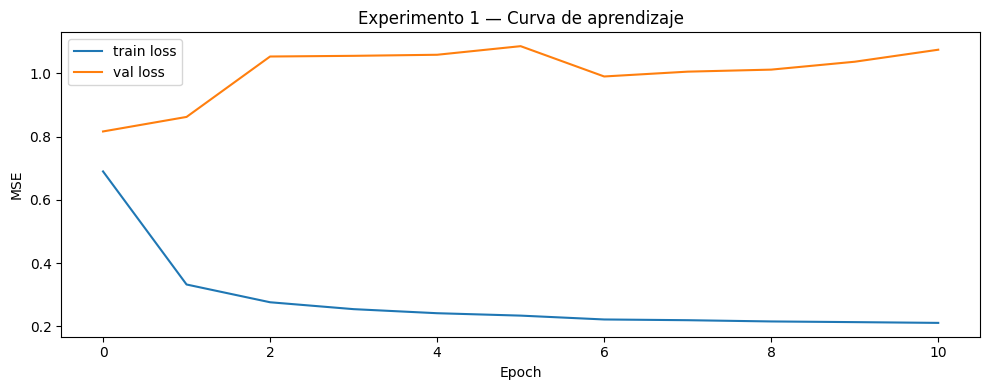

In [14]:
# Curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Experimento 1 — Curva de aprendizaje")
plt.legend(); plt.tight_layout(); plt.show()

## 6 · Evaluación en test (Experimento 1)

Calculamos R² **por tienda** y **global**, sobre ventas en euros (desnormalizadas),
usando `src/evaluate.py` — la misma función que usarán Óscar y Fernando.

> **Nota sobre la curva de aprendizaje:** la divergencia train/val visible arriba no es
> overfitting clásico, sino consecuencia de un *distribution shift* temporal — la media
> de `Sales_norm` en val es 0.40σ superior a la de train, porque las ventas crecen con el
> tiempo (tendencia capturada por `days_since_start`). Como el R² se calcula tras
> desnormalizar por tienda (no globalmente), este sesgo en escala normalizada no se
> traduce necesariamente en mal R². Lo verificamos a continuación.

In [15]:
# Predicciones en test (escala normalizada)
y_pred_norm = model.predict([X_seq_te, X_static_te], verbose=0).flatten()
print(f"Predicciones generadas: {y_pred_norm.shape}")
print(f"  Rango: [{y_pred_norm.min():.3f}, {y_pred_norm.max():.3f}]")
print(f"  Media: {y_pred_norm.mean():.3f}  Std: {y_pred_norm.std():.3f}")

Predicciones generadas: (149159,)
  Rango: [-1.835, 1.884]
  Media: 0.076  Std: 0.658


In [16]:
# Reporte de R² por tienda + GLOBAL (en escala de euros)
report_exp1 = ev.evaluation_report(df_test, y_pred_norm, store_stats)

 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.4590        4502.6992        4655.9839
     2        134  0.5875        4981.3881        4697.0444
     3        133  0.5997        6973.1429        6641.2817
     4        134  0.5500        9863.3134        9545.1484
     5        134  0.6710        4634.5522        4271.0010
   562        168  0.4758       18096.2738       18152.1152
   682        168 -0.0186       11670.5179       11104.7432
   733        168  0.3375       15514.5298       15141.2275
   769        168 -0.6575       12410.4107       11020.7139
GLOBAL       1340  0.8856       10319.9388        9920.6445


## 7 · Diagnóstico — Baselines de referencia

El R² global de 0.886 es engañoso: las tiendas individuales tienen R² entre -0.66 y 0.67.
Para entender qué parte de ese 0.886 viene del modelo y qué parte viene "gratis" por
predecir solo el nivel medio de cada tienda, comparamos contra dos baselines triviales:

- **Baseline A — Media por tienda:** predicción constante = media de Sales de esa tienda
  en train. Marca el suelo del R² que aporta solo conocer la identidad de la tienda.
- **Baseline B — Persistencia:** predicción = ventas del día anterior (mismo día de la
  semana de la semana anterior, para evitar el efecto fuerte del día de la semana).

In [17]:
# Baseline A: media de Sales por tienda (estimada en train)
mean_per_store = df_train.groupby("Store")["Sales"].mean().to_dict()

# Baseline B: persistencia con lag de 7 días (mismo día de la semana)
# Construido sobre df_test ordenado por tienda y fecha
df_test_sorted = df_test.sort_values(["Store", "Date"]).reset_index(drop=True)
df_test_sorted["Sales_lag7"] = df_test_sorted.groupby("Store")["Sales"].shift(7)

# Aplicamos el mismo "salto" de seq_len que hace build_sequences:
# por tienda, descartamos las primeras SEQ_LEN filas (que son contexto, no predicción)
from src.evaluate import TARGET_STORES
from sklearn.metrics import r2_score

def baseline_report(df_test_sorted, mean_per_store, seq_len):
    rows = []
    all_true_A, all_pred_A = [], []
    all_true_B, all_pred_B = [], []
    for sid, grp in df_test_sorted.groupby("Store"):
        if sid not in TARGET_STORES:
            continue
        grp_pred = grp.iloc[seq_len:]   # mismas filas que predice el modelo
        y_true = grp_pred["Sales"].values
        # Baseline A
        y_pred_A = np.full_like(y_true, mean_per_store.get(sid, np.nan), dtype=float)
        # Baseline B (rellena NaN del lag con la media de la tienda)
        y_pred_B = grp_pred["Sales_lag7"].fillna(mean_per_store[sid]).values
        rows.append({
            "Store": sid,
            "n": len(y_true),
            "R2_mean_baseline":        r2_score(y_true, y_pred_A),
            "R2_persistence_baseline": r2_score(y_true, y_pred_B),
        })
        all_true_A.extend(y_true); all_pred_A.extend(y_pred_A)
        all_true_B.extend(y_true); all_pred_B.extend(y_pred_B)
    rows.append({
        "Store": "GLOBAL",
        "n": len(all_true_A),
        "R2_mean_baseline":        r2_score(all_true_A, all_pred_A),
        "R2_persistence_baseline": r2_score(all_true_B, all_pred_B),
    })
    return pd.DataFrame(rows)

baselines = baseline_report(df_test_sorted, mean_per_store, SEQ_LEN)
print(baselines.to_string(index=False, float_format="{:.4f}".format))

 Store    n  R2_mean_baseline  R2_persistence_baseline
     1  133           -0.0882                  -1.8765
     2  134           -0.0042                  -1.6139
     3  133           -0.0014                  -1.7388
     4  134           -0.0501                  -1.6615
     5  134           -0.0001                  -1.7534
   562  168           -0.0138                  -0.5334
   682  168           -0.0470                  -0.3537
   733  168           -0.2172                  -1.2733
   769  168           -2.1418                  -1.3090
GLOBAL 1340            0.8131                   0.6904


### Visualización de predicciones por tienda

Para entender por qué el R² es tan desigual entre tiendas, graficamos predicción vs real
para 4 tiendas representativas: una buena (5), una media (3), y las dos problemáticas (682, 769).

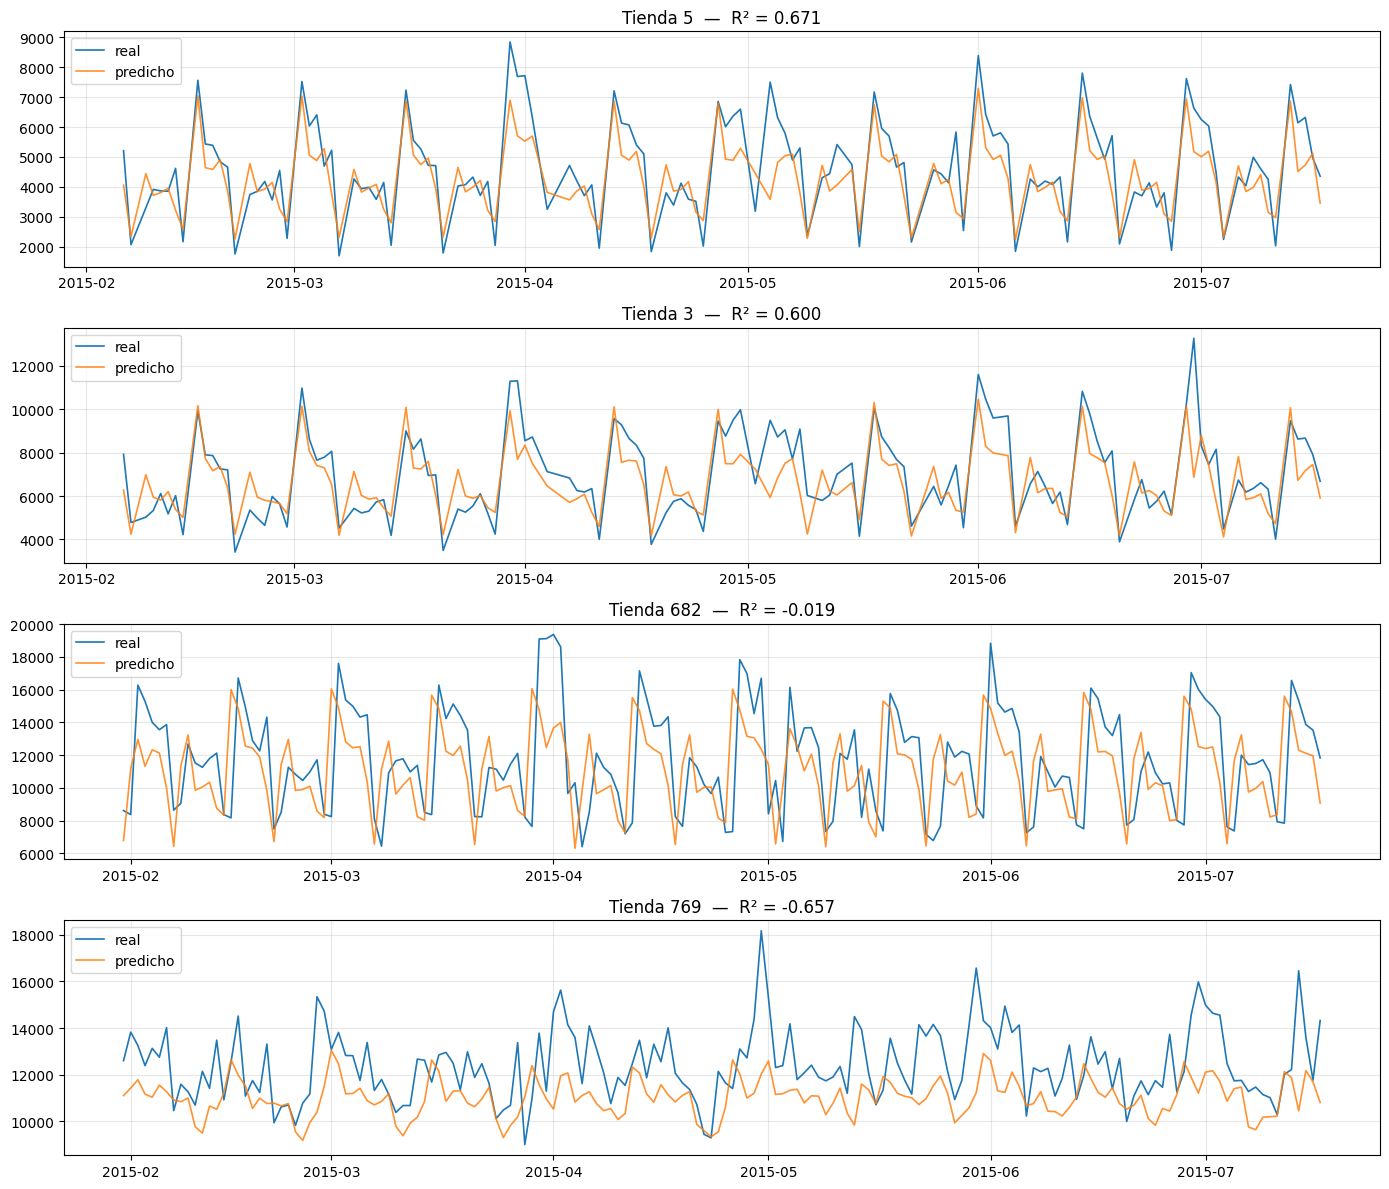

In [18]:
# Reconstruir predicciones alineadas con fechas, por tienda
def predictions_by_store(df_test, y_pred_norm, store_stats, seq_len, target_stores):
    out = {}
    cursor = 0
    for sid, grp in df_test.groupby("Store"):
        grp_sorted = grp.sort_values("Date").reset_index(drop=True)
        n_preds = max(0, len(grp_sorted) - seq_len)
        if sid in target_stores and n_preds > 0:
            grp_target = grp_sorted.iloc[seq_len:]
            stats = store_stats[int(sid)]
            y_pred_eur = np.expm1(y_pred_norm[cursor:cursor+n_preds] * stats["std"] + stats["mean"])
            out[int(sid)] = pd.DataFrame({
                "Date":    grp_target["Date"].values,
                "y_true":  grp_target["Sales"].values,
                "y_pred":  y_pred_eur,
            })
        cursor += n_preds
    return out

preds_by_store = predictions_by_store(df_test, y_pred_norm, store_stats, SEQ_LEN, TARGET_STORES)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
for ax, sid in zip(axes, [5, 3, 682, 769]):
    d = preds_by_store[sid]
    ax.plot(d["Date"], d["y_true"], label="real",      color="#1f77b4", linewidth=1.2)
    ax.plot(d["Date"], d["y_pred"], label="predicho",  color="#ff7f0e", linewidth=1.2, alpha=0.85)
    r2 = r2_score(d["y_true"], d["y_pred"])
    ax.set_title(f"Tienda {sid}  —  R² = {r2:.3f}")
    ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8 · Experimento 2 — Feature engineering avanzado

### Hipótesis
El diagnóstico del Experimento 1 muestra tres problemas:
1. La tendencia creciente de la tienda 769 no se aprende (R² = -0.66).
2. Los picos se subestiman sistemáticamente (mean-collapse moderado).
3. La diferencia con el baseline "media por tienda" es solo 0.07, indicando que la
   componente temporal aporta poco sobre la identidad de la tienda.

### Estrategia
Enriquecer la rama secuencial con **3 features derivadas del propio histórico de ventas**:

| Feature | Qué captura | Por qué ayuda |
|---------|-------------|---------------|
| `Sales_lag_7`  | Ventas hace 7 días     | Patrón semanal directo (lunes ↔ lunes) |
| `Sales_lag_14` | Ventas hace 14 días    | Robustez al ruido + tendencias quincenales |
| `Sales_roll_28`| Media móvil 28 días    | "Nivel actual" dinámico por tienda → fix para 769 |

Las tres se calculan en `Sales_norm` (mismo espacio numérico) y con `.shift(1)`
previo para garantizar ausencia de leakage (el día t solo ve hasta t-1).

Mantenemos `src/preprocessing.py` intacto (contrato del equipo) y creamos
`src/preprocessing_dani.py` con las funciones nuevas.